In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [8]:
import pandas as pd
import numpy as np


file_path = "/content/AB_road_transport_CO2_per_tkm.xlsx"
freight = pd.read_excel(file_path)


freight.columns = freight.columns.str.strip()

print("Loaded:", freight.shape)
print("Columns:", list(freight.columns))
display(freight.head())


Loaded: (198, 5)
Columns: ['Country', 'Year', 'TonKm', 'CO2', 'CO2_per_tkm_kg']


,Country,Year,TonKm,CO2,CO2_per_tkm_kg
0,Bulgaria,2015,161567,1377240.04,8.524266
1,Czechia,2015,438907,1693810.67,3.859156
2,Germany,2015,3035329,1913753.97,0.630493
3,Estonia,2015,28162,1838197.77,65.272274
4,Ireland,2015,117090,2143578.78,18.307104


In [9]:
import pandas as pd
import numpy as np


df = freight.copy()

df = df.dropna(subset=['CO2', 'TonKm', 'Year'])


df = df[df['Year'] <= 2022]


df['log_CO2'] = np.log(df['CO2'])
df['log_TonKm'] = np.log(df['TonKm'])

print("Final panel shape:", df.shape)
df.head()


Final panel shape: (170, 7)


,Country,Year,TonKm,CO2,CO2_per_tkm_kg,log_CO2,log_TonKm
0,Bulgaria,2015,161567,1377240.04,8.524266,14.135592,11.992675
1,Czechia,2015,438907,1693810.67,3.859156,14.342491,12.992043
2,Germany,2015,3035329,1913753.97,0.630493,14.464577,14.925830
3,Estonia,2015,28162,1838197.77,65.272274,14.424296,10.245729
4,Ireland,2015,117090,2143578.78,18.307104,14.577987,11.670698


In [10]:
import statsmodels.api as sm

X = df[['log_TonKm']]
y = df['log_CO2']

X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                log_CO2   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.002
Date:                Sun, 19 Apr 2026   Prob (F-statistic):              0.159
Time:                        12:40:46   Log-Likelihood:                 34.357
No. Observations:                 170   AIC:                            -64.71
Df Residuals:                     168   BIC:                            -58.44
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.5744      0.164     88.658      0.0

,Feature,Importance
0,TonKm,0.922099
1,Year,0.077901


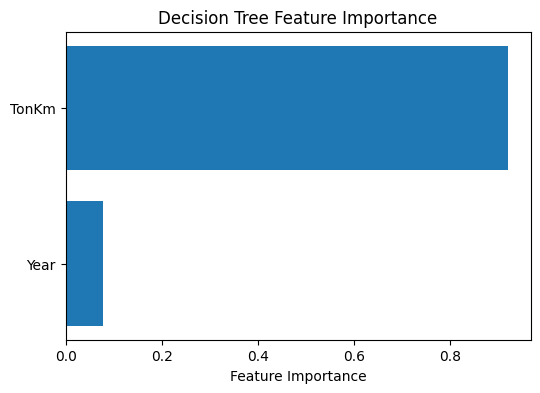

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

display(feature_importance)

# Plot
plt.figure(figsize=(6,4))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Feature Importance")
plt.title("Decision Tree Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


X = df[['TonKm', 'Year']]
y = df['CO2']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


dt_model = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)


y_pred = dt_model.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, y_pred))
print("Decision Tree R²:", r2_score(y_test, y_pred))


Decision Tree MSE: 70829547685.05484
Decision Tree R²: 0.26726890217403065


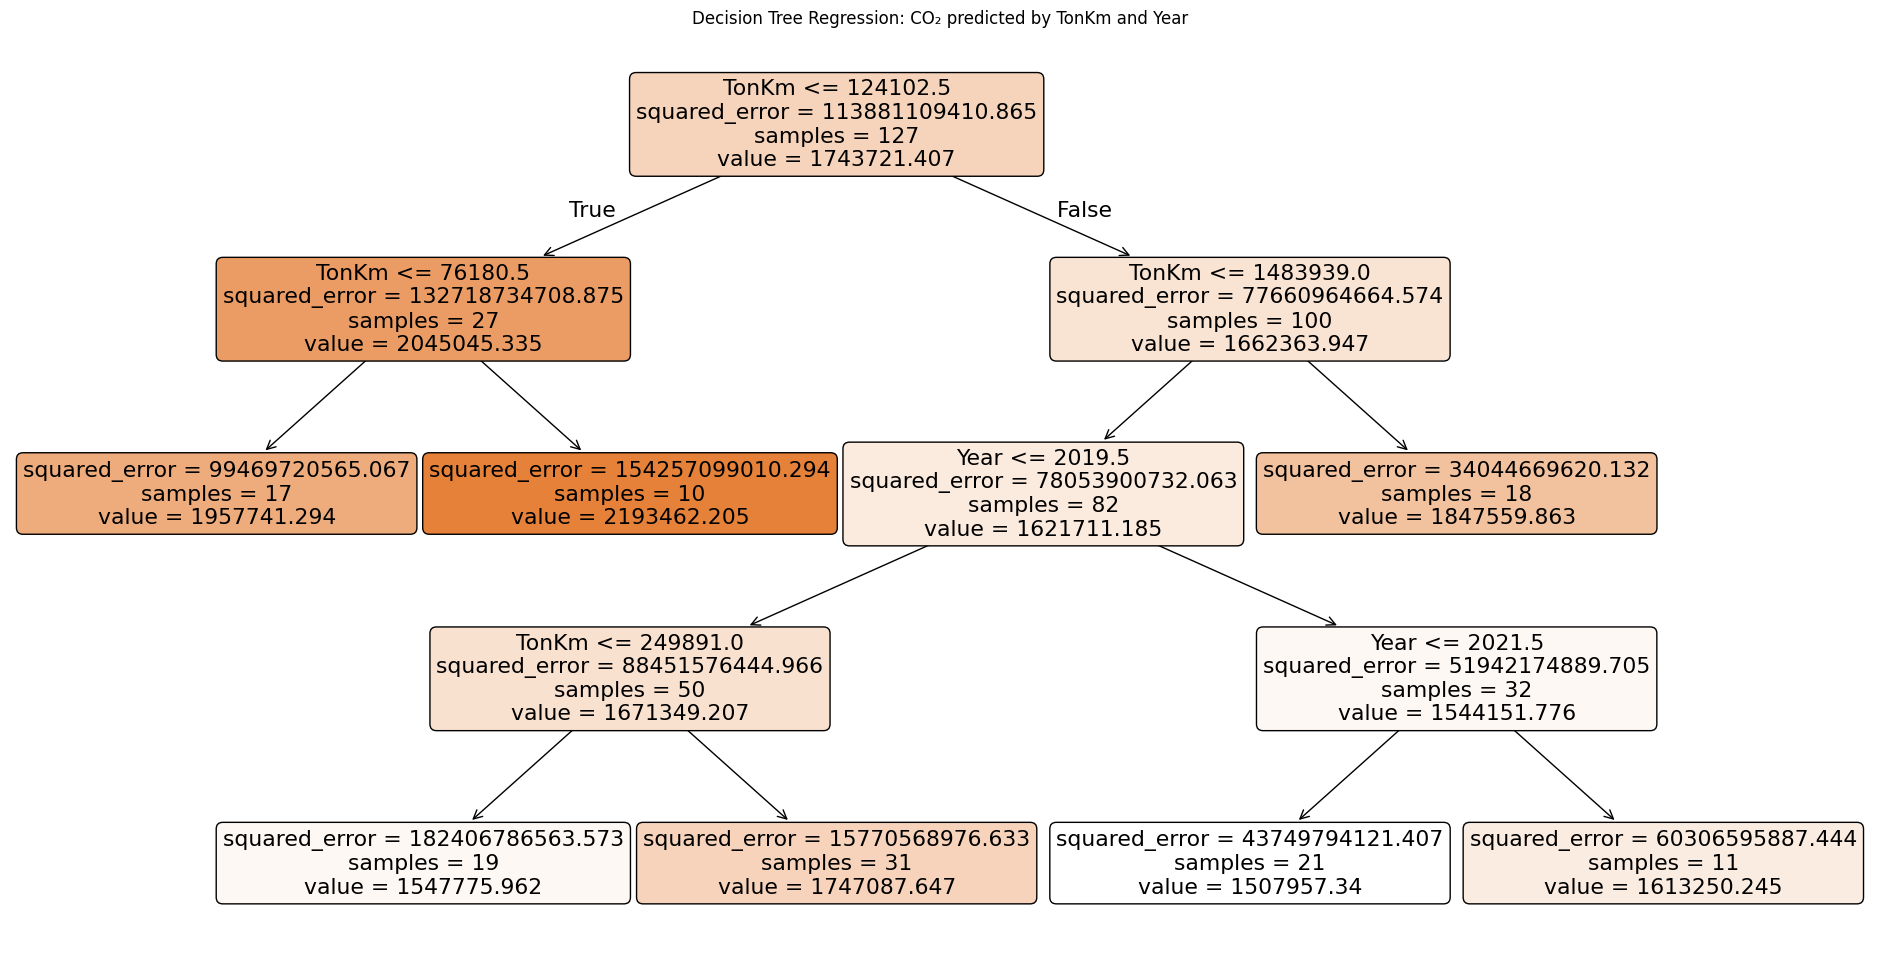

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Regression: CO₂ predicted by TonKm and Year")
plt.show()


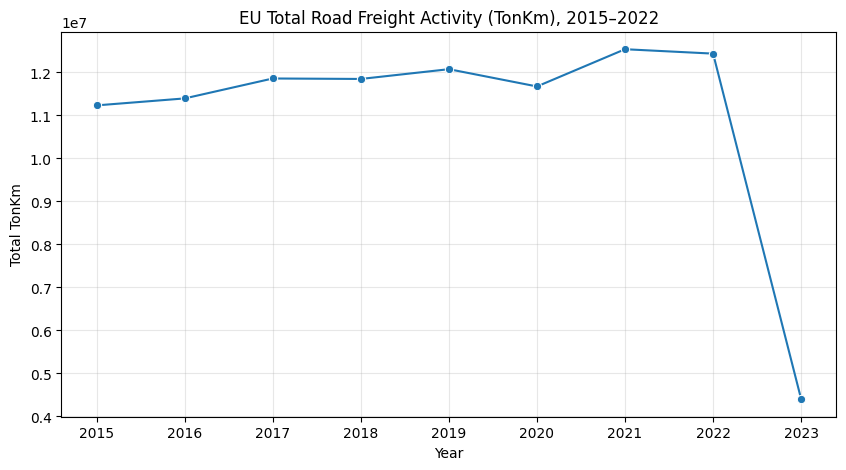

In [21]:
yearly_sum = df.groupby('Year')[['TonKm', 'CO2']].sum().reset_index()
yearly_intensity_weighted = yearly_sum.copy()
yearly_intensity_weighted['CO2_per_tkm_kg'] = yearly_sum['CO2'] / yearly_sum['TonKm']

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sum, x='Year', y='TonKm', marker='o')
plt.title('EU Total Road Freight Activity (TonKm), 2015–2022')
plt.xlabel('Year')
plt.ylabel('Total TonKm')
plt.grid(True, alpha=0.3)
plt.show()

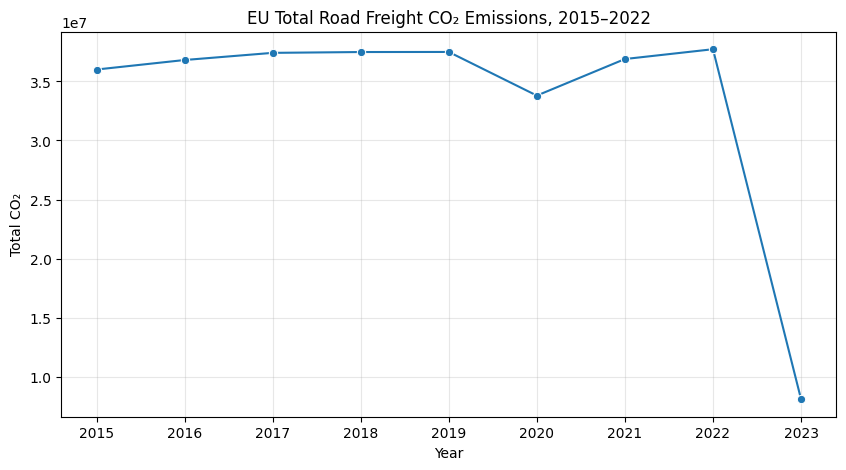

In [22]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_sum, x='Year', y='CO2', marker='o')
plt.title('EU Total Road Freight CO₂ Emissions, 2015–2022')
plt.xlabel('Year')
plt.ylabel('Total CO₂')
plt.grid(True, alpha=0.3)
plt.show()


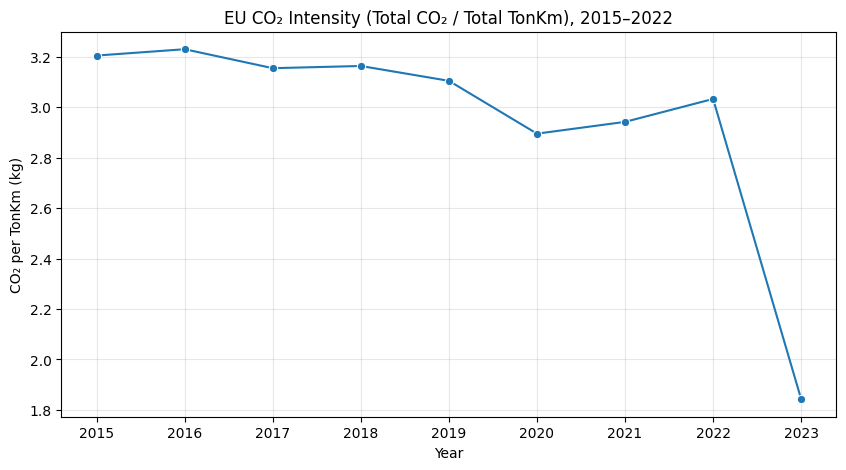

In [23]:
plt.figure(figsize=(10,5))
sns.lineplot(data=yearly_intensity_weighted, x='Year', y='CO2_per_tkm_kg', marker='o')
plt.title('EU CO₂ Intensity (Total CO₂ / Total TonKm), 2015–2022')
plt.xlabel('Year')
plt.ylabel('CO₂ per TonKm (kg)')
plt.grid(True, alpha=0.3)
plt.show()


In [16]:
import numpy as np
import pandas as pd


df = freight.copy()

df = df.dropna(subset=['CO2', 'TonKm', 'Year'])


df['log_CO2'] = np.log(df['CO2'])
df['log_TonKm'] = np.log(df['TonKm'])

print("Observations:", df.shape[0])
df.head()


Observations: 175


,Country,Year,TonKm,CO2,CO2_per_tkm_kg,log_CO2,log_TonKm
0,Bulgaria,2015,161567,1377240.04,8.524266,14.135592,11.992675
1,Czechia,2015,438907,1693810.67,3.859156,14.342491,12.992043
2,Germany,2015,3035329,1913753.97,0.630493,14.464577,14.925830
3,Estonia,2015,28162,1838197.77,65.272274,14.424296,10.245729
4,Ireland,2015,117090,2143578.78,18.307104,14.577987,11.670698


In [24]:
# OLS predictions
df['pred_log_co2'] = ols_model.predict(X)

# Residuals
df['residual'] = df['log_CO2'] - df['pred_log_co2']

# Absolute deviation
df['abs_residual'] = abs(df['residual'])

# Top deviating countries
outliers = df.sort_values(by='abs_residual', ascending=False)

outliers[['Country', 'Year', 'TonKm', 'CO2', 'residual']].head(10)

,Country,Year,TonKm,CO2,residual
90,Germany,2019,3208232,1906218.36,-4.675802e+07
68,Germany,2018,3200925,1904970.62,-4.665152e+07
46,Germany,2017,3161837,1921685.61,-4.608184e+07
112,Germany,2020,3119646,1655608.69,-4.546693e+07
24,Germany,2016,3111858,1915230.58,-4.535343e+07
134,Germany,2021,3107981,1641965.65,-4.529692e+07
156,Germany,2022,3060964,1663037.38,-4.461168e+07
2,Germany,2015,3035329,1913753.97,-4.423806e+07
7,France,2015,1796755,1763835.05,-2.618658e+07
29,France,2016,1727611,1765044.43,-2.517885e+07


In [25]:
country_dev = df.groupby('Country')['residual'].mean().sort_values()

print(country_dev)

Country
Germany       -4.555730e+07
France        -2.419541e+07
Poland        -2.123703e+07
Spain         -2.122564e+07
Netherlands   -9.851685e+06
Czechia       -6.826676e+06
Sweden        -6.716251e+06
Austria       -5.605093e+06
Switzerland   -4.319367e+06
Greece        -4.088222e+06
Finland       -3.900611e+06
Norway        -3.792547e+06
Romania       -3.703633e+06
Hungary       -2.927214e+06
Slovakia      -2.420670e+06
Portugal      -2.168352e+06
Bulgaria      -2.134275e+06
Ireland       -2.127615e+06
Slovenia      -1.279867e+06
Latvia        -1.061248e+06
Luxembourg    -7.131375e+05
Estonia       -4.151548e+05
Name: residual, dtype: float64


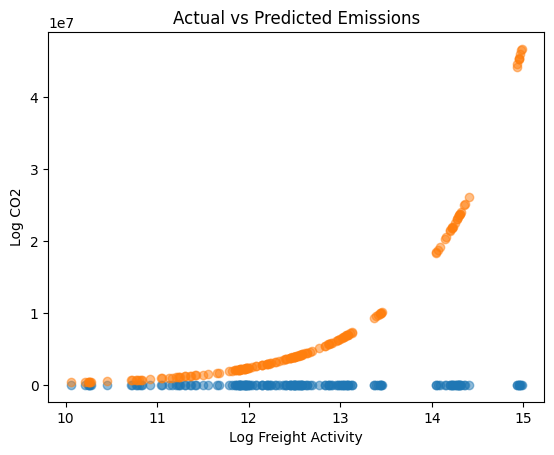

In [26]:
import matplotlib.pyplot as plt

plt.scatter(df['log_TonKm'], df['log_CO2'], alpha=0.5)
plt.scatter(df['log_TonKm'], df['pred_log_co2'], alpha=0.5)

plt.xlabel("Log Freight Activity")
plt.ylabel("Log CO2")
plt.title("Actual vs Predicted Emissions")
plt.show()

In [27]:
df['pred_co2'] = np.exp(df['pred_log_co2'])
df['actual_co2'] = df['CO2']

df['deviation'] = df['actual_co2'] - df['pred_co2']
df['deviation_pct'] = df['deviation'] / df['pred_co2']

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [28]:
df.to_csv("eu_freight_emissions_dashboard.csv", index=False)

In [32]:
import numpy as np


df['pred_co2'] = np.exp(df['pred_log_co2'])


df['actual_co2'] = df['CO2']


df['deviation'] = df['actual_co2'] - df['pred_co2']


df['deviation_pct'] = (df['actual_co2'] - df['pred_co2']) / df['pred_co2']


print(df[['pred_co2','actual_co2','deviation_pct']].head())
print(df['deviation_pct'].isna().sum())

   pred_co2  actual_co2  deviation_pct
0       inf  1377240.04            NaN
1       inf  1693810.67            NaN
2       inf  1913753.97            NaN
3       inf  1838197.77            NaN
4       inf  2143578.78            NaN
175


In [33]:
df.to_csv("final_dashboard_clean.csv", index=False)